In [1]:
import numpy as np
import pandas as pd
import os

import random
from PIL import Image, ImageDraw
from collections import Counter
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

import torch
import torchvision
from torchvision import transforms as T
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

In [2]:
from google.colab import drive

drive.mount("/content/drive")

%cd '/content/drive/MyDrive/Project/Colab Notebooks/'

Mounted at /content/drive
[Errno 2] No such file or directory: '/content/drive/MyDrive/Project/Colab Notebooks/'
/content


In [4]:
# Read in annoted data
train = pd.read_csv('/content/drive/MyDrive/fall.v1-fall2022-03-30.tensorflow/train/_annotations.csv')
train['label'] = train['class'].apply(lambda x: 1 if x == 'fall' else 0)
train.drop(columns=['width', 'height', 'class'], inplace=True)
print(train.head(3))

test=pd.read_csv('/content/drive/MyDrive/fall.v1-fall2022-03-30.tensorflow/test/_annotations.csv')
test['label'] = test['class'].apply(lambda x: 1 if x == 'fall' else 0)
test.drop(columns=['width', 'height', 'class'], inplace=True)
print(test.head(3))

valid=pd.read_csv('/content/drive/MyDrive/fall.v1-fall2022-03-30.tensorflow/valid/_annotations.csv')
valid['label'] = valid['class'].apply(lambda x: 1 if x == 'fall' else 0)
valid.drop(columns=['width', 'height', 'class'], inplace=True)
print(valid.head(3))

print('-------------------------------------')

whole = pd.concat([train, test, valid], ignore_index=True)

#Check numbers of imgs
train_unique_imgs=train.filename.unique()
print('Num of train:',len(train_unique_imgs))
test_unique_imgs=test.filename.unique()
print('Num of test:',len(test_unique_imgs))
valid_unique_imgs=valid.filename.unique()
print('Num of valid:',len(valid_unique_imgs))
print('-------------------------------------')
whole_unique_imgs=whole.filename.unique()
print('Num of whole:',len(whole_unique_imgs))


                                            filename  xmin  ymin  xmax  ymax  \
0  people-8711-_jpg.rf.bff63ec5f1b863d535234d0af2...    22    89   393   325   
1  people-2693-_jpg.rf.c023e0da53c04d5eb3167460f4...   166   140   286   183   
2  people-6785-_jpg.rf.c03fd516fa32a61b28d2c0fb7a...    17   187   223   367   

   label  
0      1  
1      1  
2      1  
                                            filename  xmin  ymin  xmax  ymax  \
0  people-4752-_jpg.rf.010ef79400fc534837828b584d...   174   132   413   407   
1  people-1741-_jpg.rf.011b833c769ee77c3482d96cbe...     0   162   344   391   
2  people-3001-_jpg.rf.014fb6a76ed6e4c3e9bbc69e6e...   159   254   297   380   

   label  
0      1  
1      1  
2      1  
                                            filename  xmin  ymin  xmax  ymax  \
0  people-6358-_jpg.rf.0039d97395c8f6d54527883932...    92   135   329   375   
1  people-3989-_jpg.rf.01779b521396b19e3eebaf3bbd...    60   243   350   415   
2  people-3226-_jpg.rf.0243e25

In [5]:
class CustDat(torch.utils.data.Dataset):
    def __init__(self, df, unique_imgs, indices):
        self.df=df
        self.unique_imgs=unique_imgs
        self.indices=indices
    def __len__(self):
        return len(self.indices)
    def __getitem__(self,idx):
        image_name=self.unique_imgs[self.indices[idx]]
        boxes=self.df[self.df.filename==image_name].values[:,1:5].astype('float32')
        img=Image.open('/content/drive/MyDrive/fall.v1-fall2022-03-30.tensorflow/Whole/'+image_name).convert('RGB')
        labels=self.df[self.df.filename==image_name].values[:,-1].astype('int64')
        target={}
        target['boxes']=torch.tensor(boxes)
        target['label']=torch.tensor(labels)
        return T.ToTensor()(img),target

def custom_collate(data):
    return data

In [6]:
#Split data into train and test
unique_imgs=whole.filename.unique()
train_inds,test_inds=train_test_split(range(unique_imgs.shape[0]),test_size=0.2,random_state=42)

print(len(train_inds),len(test_inds))

#Load data
train_dl=torch.utils.data.DataLoader(CustDat(whole,unique_imgs,train_inds),batch_size=16,shuffle=True,collate_fn=custom_collate,
                                     pin_memory=True if torch.cuda.is_available() else False)

test_dl=torch.utils.data.DataLoader(CustDat(whole,unique_imgs,test_inds),batch_size=8,shuffle=True,collate_fn=custom_collate,
                                     pin_memory=True if torch.cuda.is_available() else False)

# for data in test_dl:
#     print(data)

3585 897


In [7]:
#Load model and define essential hyperparameters
model=torchvision.models.detection.fasterrcnn_resnet50_fpn(weights=True)
num_classes=2
in_features=model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor=FastRCNNPredictor(in_features,num_classes)

device=torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
print(device)

optimizer=torch.optim.SGD(model.parameters(),lr=0.001,momentum=0.9,weight_decay=0.0005)
num_epoch=15

/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=FasterRCNN_ResNet50_FPN_Weights.COCO_V1`. You can also use `weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth
100%|██████████| 160M/160M [00:01<00:00, 94.5MB/s]


cuda


Epoch [1/15], Train Loss: 47.03104070574045, Test Loss: 16.76988159120083
Epoch [2/15], Train Loss: 31.35024343430996, Test Loss: 14.808175839483738
Epoch [3/15], Train Loss: 27.900890413671732, Test Loss: 13.776004567742348
Epoch [4/15], Train Loss: 25.65583687275648, Test Loss: 13.222461804747581
Epoch [5/15], Train Loss: 23.906136017292738, Test Loss: 12.813969504088163
Epoch [6/15], Train Loss: 22.396895486861467, Test Loss: 12.746214505285025
Epoch [7/15], Train Loss: 21.183627106249332, Test Loss: 12.61484194546938
Epoch [8/15], Train Loss: 20.096511773765087, Test Loss: 12.56481746211648
Epoch [9/15], Train Loss: 19.064467273652554, Test Loss: 12.497846085578203
Epoch [10/15], Train Loss: 18.201792810112238, Test Loss: 12.377443790435791
Epoch [11/15], Train Loss: 17.414232280105352, Test Loss: 12.417568448930979
Epoch [12/15], Train Loss: 16.49033449962735, Test Loss: 12.128422191366553
Epoch [13/15], Train Loss: 15.745229493826628, Test Loss: 12.286068830639124
Epoch [14/15], 

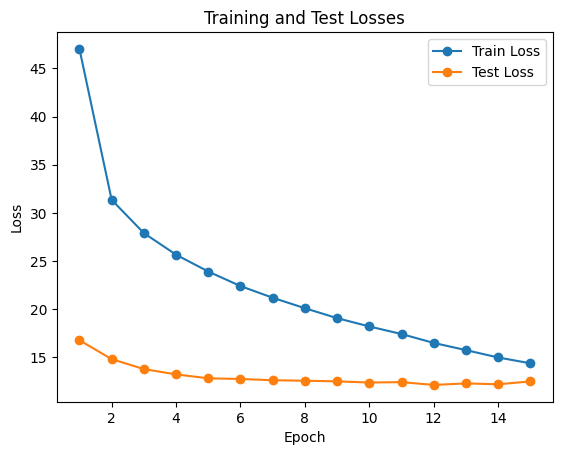

In [8]:
# Train model
model.to(device)
train_losses = []
test_losses = []

for epoch in range(num_epoch):
    train_loss = 0
    for i, train_data in enumerate(train_dl):
        train_imgs = []
        train_labels = []
        for d in train_data:
            train_imgs.append(d[0].to(device))
            label = {'boxes': d[1]['boxes'].to(device), 'labels': d[1]['label'].to(device)}
            train_labels.append(label)

        loss_dict = model(train_imgs, train_labels)
        loss = sum(v for v in loss_dict.values())
        train_loss += loss.item()
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    train_losses.append(train_loss)

    # Evaluate on test data
    test_loss = 0
    with torch.no_grad():
        for test_data in test_dl:
            test_imgs = []
            test_labels = []
            for d in test_data:
                test_imgs.append(d[0].to(device))
                label = {'boxes': d[1]['boxes'].to(device), 'labels': d[1]['label'].to(device)}
                test_labels.append(label)

            test_loss_dict = model(test_imgs, test_labels)
            test_loss += sum(v for v in test_loss_dict.values()).item()

    test_losses.append(test_loss)

    print(f"Epoch [{epoch+1}/{num_epoch}], Train Loss: {train_losses[-1]}, Test Loss: {test_losses[-1]}")

# Plot both training and test losses
plt.plot(range(1, num_epoch + 1), train_losses, marker='o', label='Train Loss')
plt.plot(range(1, num_epoch + 1), test_losses, marker='o', label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Test Losses')
plt.legend()
plt.grid(False)
plt.show()

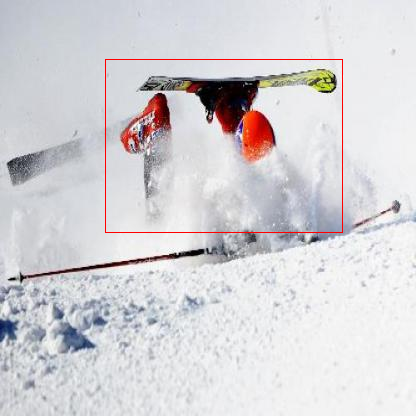

In [41]:
# Run inference on one test sample
model.eval()
data = next(iter(test_dl))

img = data[0][0].to(device)
boxes = data[0][1]['boxes']
labels = data[0][1]['label']

output = model([img])

# Display inference
output_boxes = output[0]['boxes']
output_scores = output[0]['scores']
keep = torchvision.ops.nms(output_boxes, output_scores, 0.9)

im = (img.permute(1, 2, 0).cpu().detach().numpy() * 255).astype('uint8')
vsample = Image.fromarray(im)

draw = ImageDraw.Draw(vsample)
for box in output_boxes[keep]:
    draw.rectangle([(box[0], box[1]), (box[2], box[3])], outline='red')

vsample

In [ ]:
from sklearn.metrics import precision_recall_curve
import numpy as np


# Function to calculate IoU between two bounding boxes
def calculate_iou(box1, box2):
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])

    intersection_area = max(0, x2 - x1 + 1) * max(0, y2 - y1 + 1)

    box1_area = (box1[2] - box1[0] + 1) * (box1[3] - box1[1] + 1)
    box2_area = (box2[2] - box2[0] + 1) * (box2[3] - box2[1] + 1)

    union_area = box1_area + box2_area - intersection_area

    iou = intersection_area / union_area
    return iou

# Function to calculate Average Precision (AP) for one image
def calculate_ap(ground_truth_boxes, filtered_output_boxes, iou_threshold=0.5):
    iou_matrix = np.zeros((len(ground_truth_boxes), len(filtered_output_boxes)))
    for i, gt_box in enumerate(ground_truth_boxes):
        for j, pred_box in enumerate(filtered_output_boxes):
            iou_matrix[i, j] = calculate_iou(gt_box, pred_box)

    precisions = []
    recalls = []

    for threshold in np.arange(0.5, 1.0, 0.05):
        tp = 0
        fp = 0
        fn = 0
        for i in range(len(ground_truth_boxes)):
            for j in range(len(filtered_output_boxes)):
                if iou_matrix[i, j] >= threshold:
                    tp += 1
                else:
                    fp += 1
        fn = len(ground_truth_boxes) - tp

        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0

        precisions.append(precision)
        recalls.append(recall)

    precisions = np.array(precisions)
    recalls = np.array(recalls)
    ap = np.trapz(precisions, recalls)

    return ap

# Calculate mAP for all images
all_aps = []
for data in test_dl:
    img = data[0][0].to(device)
    boxes = data[0][1]['boxes']
    labels = data[0][1]['label']

    output = model([img])

    output_boxes = output[0]['boxes']
    output_scores = output[0]['scores']

    keep = torchvision.ops.nms(output_boxes, output_scores, 0.9)
    filtered_output_boxes = output_boxes[keep].cpu().detach().numpy()

    ground_truth_boxes = [box.cpu().detach().numpy() for box in boxes]

    ap = calculate_ap(ground_truth_boxes, filtered_output_boxes)
    all_aps.append(ap)

# Calculate mAP
mAP = np.mean(all_aps)
print("mAP:", mAP)


mAP: -0.24609336091636977


In [54]:
# Function to calculate overall accuracy, precision, recall rate for all images
def calculate_accuracy_precision_recall(model, test_dl, device):
    total_tp = 0
    total_fp = 0
    total_fn = 0
    total_objects = 0

    for data in test_dl:
        img = data[0][0].to(device)
        boxes = data[0][1]['boxes']
        labels = data[0][1]['label']

        output = model([img])

        output_boxes = output[0]['boxes']
        output_scores = output[0]['scores']

        keep = torchvision.ops.nms(output_boxes, output_scores, 0.5)
        filtered_output_boxes = output_boxes[keep].cpu().detach().numpy()

        ground_truth_boxes = [box.cpu().detach().numpy() for box in boxes]

        num_gt_objects = len(ground_truth_boxes)
        total_objects += num_gt_objects

        num_detected_objects = len(filtered_output_boxes)
        tp = 0
        fp = num_detected_objects
        for i in range(num_gt_objects):
            for j in range(num_detected_objects):
                iou = calculate_iou(ground_truth_boxes[i], filtered_output_boxes[j])
                if iou >= 0.5:
                    tp += 1
                    fp -= 1
                    break  
        fn = num_gt_objects - tp
        total_tp += tp
        total_fp += fp
        total_fn += fn

    overall_accuracy = total_tp / total_objects if total_objects > 0 else 0
    overall_precision = total_tp / (total_tp + total_fp) if (total_tp + total_fp) > 0 else 0
    overall_recall = total_tp / (total_tp + total_fn) if (total_tp + total_fn) > 0 else 0

    return overall_accuracy, overall_precision, overall_recall

overall_accuracy, overall_precision, overall_recall = calculate_accuracy_precision_recall(model, test_dl, device)

print("Overall Accuracy:", overall_accuracy)
print("Overall Precision:", overall_precision)
print("Overall Recall Rate:", overall_recall)


Overall Accuracy: 0.9646017699115044
Overall Precision: 0.3343558282208589
Overall Recall Rate: 0.9646017699115044
